# Exercise 3: Bias in the Data

**Authors**: 
- Pedro Fernandez Tonso : 3983781

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

np.random.seed(42)


## 1. Load and Prepare Data

In [4]:
def load_arff(file_path):
    ar, meta = arff.loadarff(file_path)
    return pd.DataFrame(ar), meta

file_path = Path('../databank/00_raw/uci-large/credit-a.arff')
if not file_path.exists():
    file_path = Path('dq-lab-1/databank/00_raw/uci-large/credit-a.arff')

data, _ = load_arff(file_path)
data.dropna(inplace=True)

for col, typ in zip(data.columns, data.dtypes):
    if typ == 'object':
        data[col] = data[col].map(lambda x: x.decode() if isinstance(x, bytes) else x)

X = pd.get_dummies(data.drop('class', axis=1))
X = X.drop([col for col in X.columns if col.endswith('_?')], axis=1)
y = data['class']


## 2. Bias Experiment Function

In [6]:
def run_bias_experiment(
        X, y, group, 
        basis_val, other_val=None, 
        ratios=[0.05 * i for i in range(20)], 
        seed=42
    ):
    np.random.seed(seed)
    
    mask_A = group == basis_val
    mask_B = (group == other_val) if other_val is not None else ((group != basis_val) & (group != '?'))
    
    X_A, y_A = X[mask_A], y[mask_A]
    X_B, y_B = X[mask_B], y[mask_B]
    
    X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A, y_A, test_size=0.2, random_state=seed)
    X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y_B, test_size=0.2, random_state=seed)
    
    X_test_comb = pd.concat([X_test_A, X_test_B])
    y_test_comb = pd.concat([y_test_A, y_test_B])
    
    n_A = len(X_train_A)
    acc_A, acc_B, acc_comb = [], [], []
    
    for r in ratios:
        n_replace = int(n_A * r)
        n_keep = n_A - n_replace
        
        idx_A = np.random.choice(len(X_train_A), size=n_keep, replace=True)
        idx_B = np.random.choice(len(X_train_B), size=n_replace, replace=True)
        
        X_train_curr = pd.concat([X_train_A.iloc[idx_A], X_train_B.iloc[idx_B]])
        y_train_curr = pd.concat([y_train_A.iloc[idx_A], y_train_B.iloc[idx_B]])
        
        clf = GaussianNB()
        clf.fit(X_train_curr, y_train_curr)
        
        acc_A.append(accuracy_score(y_test_A, clf.predict(X_test_A)))
        acc_B.append(accuracy_score(y_test_B, clf.predict(X_test_B)))
        acc_comb.append(accuracy_score(y_test_comb, clf.predict(X_test_comb)))
        
    return ratios, acc_A, acc_B, acc_comb


def plot_bias_experiment(ratios, acc_A, acc_B, acc_comb, label_A, label_B, title):
    plt.figure(figsize=(7, 4))
    plt.plot(ratios, acc_A, marker='o', label=label_A)
    plt.plot(ratios, acc_B, marker='o', label=label_B)
    plt.plot(ratios, acc_comb, marker='o', label='Test Combined', linestyle='--')
    plt.xlabel('Bias Ratio (Other in training)')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


## 3. Bias in Binary Attribute A9 (Prior)

Ratio 0.00 | Test A: 0.7606 | Test B: 0.6190 | Combined: 0.6940
Ratio 0.05 | Test A: 0.7183 | Test B: 0.8413 | Combined: 0.7761
Ratio 0.10 | Test A: 0.7465 | Test B: 0.9206 | Combined: 0.8284
Ratio 0.15 | Test A: 0.7746 | Test B: 0.9683 | Combined: 0.8657
Ratio 0.20 | Test A: 0.7465 | Test B: 0.9365 | Combined: 0.8358
Ratio 0.25 | Test A: 0.7324 | Test B: 0.9365 | Combined: 0.8284
Ratio 0.30 | Test A: 0.7465 | Test B: 0.9206 | Combined: 0.8284
Ratio 0.35 | Test A: 0.8169 | Test B: 0.9365 | Combined: 0.8731
Ratio 0.40 | Test A: 0.7746 | Test B: 0.9206 | Combined: 0.8433
Ratio 0.45 | Test A: 0.8028 | Test B: 0.9206 | Combined: 0.8582
Ratio 0.50 | Test A: 0.7465 | Test B: 0.9048 | Combined: 0.8209
Ratio 0.55 | Test A: 0.7746 | Test B: 0.9206 | Combined: 0.8433
Ratio 0.60 | Test A: 0.7324 | Test B: 0.9206 | Combined: 0.8209
Ratio 0.65 | Test A: 0.8310 | Test B: 0.9206 | Combined: 0.8731
Ratio 0.70 | Test A: 0.8028 | Test B: 0.9206 | Combined: 0.8582
Ratio 0.75 | Test A: 0.7606 | Test B: 0.

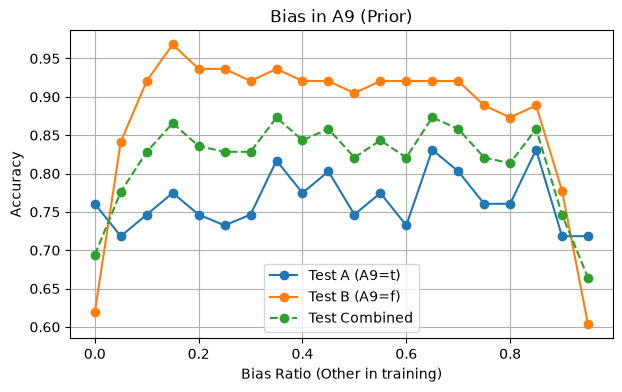

In [8]:
ratios, acc_a, acc_b, acc_comb = run_bias_experiment(X, y, data['A9'], basis_val='t', other_val='f')

for r, a, b, c in zip(ratios, acc_a, acc_b, acc_comb):
    print(f"Ratio {r:.2f} | Test A: {a:.4f} | Test B: {b:.4f} | Combined: {c:.4f}")

plot_bias_experiment(ratios, acc_a, acc_b, acc_comb, 'Test A (A9=t)', 'Test B (A9=f)', 'Bias in A9 (Prior)')


In [ ]:
print(pd.crosstab(data['A9'], data['class'], margins=True))
print()
print(pd.crosstab(data['A9'], data['class'], normalize='index').round(4))

class    +    -  All
A9                  
f       19  295  314
t      280   72  352
All    299  367  666

class       +       -
A9                   
f      0.0605  0.9395
t      0.7955  0.2045


## 4. Bias in Multi-Category Attribute A4 (Marital Status)

Ratio 0.00 Other | Test A4=y: 0.7188 | Test A4!=y: 0.7549 | Combined: 0.7463
Ratio 0.05 Other | Test A4=y: 0.8125 | Test A4!=y: 0.5882 | Combined: 0.6418
Ratio 0.10 Other | Test A4=y: 0.7500 | Test A4!=y: 0.6275 | Combined: 0.6567
Ratio 0.15 Other | Test A4=y: 0.6250 | Test A4!=y: 0.7157 | Combined: 0.6940
Ratio 0.20 Other | Test A4=y: 0.7500 | Test A4!=y: 0.7843 | Combined: 0.7761
Ratio 0.25 Other | Test A4=y: 0.8125 | Test A4!=y: 0.7941 | Combined: 0.7985
Ratio 0.30 Other | Test A4=y: 0.8438 | Test A4!=y: 0.8333 | Combined: 0.8358
Ratio 0.35 Other | Test A4=y: 0.7812 | Test A4!=y: 0.7451 | Combined: 0.7537
Ratio 0.40 Other | Test A4=y: 0.7500 | Test A4!=y: 0.7549 | Combined: 0.7537
Ratio 0.45 Other | Test A4=y: 0.6875 | Test A4!=y: 0.7549 | Combined: 0.7388
Ratio 0.50 Other | Test A4=y: 0.7188 | Test A4!=y: 0.7745 | Combined: 0.7612
Ratio 0.55 Other | Test A4=y: 0.6875 | Test A4!=y: 0.7549 | Combined: 0.7388
Ratio 0.60 Other | Test A4=y: 0.8125 | Test A4!=y: 0.8333 | Combined: 0.8284

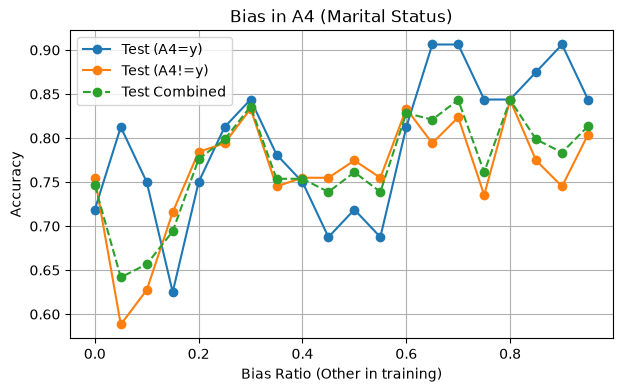

In [11]:
ratios, acc_y, acc_other, acc_comb = run_bias_experiment(X, y, data['A4'], basis_val='y')

for r, a, b, c in zip(ratios, acc_y, acc_other, acc_comb):
    print(f"Ratio {r:.2f} Other | Test A4=y: {a:.4f} | Test A4!=y: {b:.4f} | Combined: {c:.4f}")

plot_bias_experiment(ratios, acc_y, acc_other, acc_comb, 'Test (A4=y)', 'Test (A4!=y)', 'Bias in A4 (Marital Status)')


## Experiment interpretation
We take a single feature A1, and split our data into groups where group A is `A1=='a'` vs group B is `A1=='b'`.

The test set is a fixed balanced benchmark, with $20\%$ of group A and $20\%$ of group B.

The total train set is fixed at $\mathtt{n}=\mathrm{size}(\mathrm{Train}_A)$.

We start at fully biased training set $100\%$ rows from group A. as we increase the ratio, we replace $r \cdot \mathtt{n}$ rows of A with rows from B, sampled with replacement.

At each step, we evaluate on $\mathrm{Test}_A$, $\mathrm{Test}_B$ and $\mathrm{Test}_{\text{Combined}}$



## Takeaways

We chosed 'A9' prior variable as input, as we discovered in experiment 1 that this is a useful boolean variable for the model. 'A9' is a special variable highly correlated with our output.

1. At Ratio 0.00, the model was trained only on A9='t', meagning it got really biased around approved cases, overpredicting a

### Observations & Explanations

1. **At 0.00 Bias (Trained only on $A9=t$)**:
   * **Observation**: Test A achieves $76.1\%$ accuracy, while Test B drops to $61.9\%$.
   * **Explanation**: The model has never seen $A9=f$ and inherits the positive bias of $A9=t$ ($80\%$ approved), misclassifying true negative instances in Test B.

2. **Between 0.05 and 0.85 Bias**:
   * **Observation**: Test B accuracy jumps immediately to $\sim 92\%-96\%$ and remains consistently higher than Test A ($\sim 75\%-80\%$).
   * **Explanation**: $93.9\%$ of $A9=f$ cases are rejected (`-`). As soon as the model sees $5\%$ of $A9=f$, predicting this almost homogeneous group becomes trivial. In contrast, $A9=t$ is mixed ($80\%$ `+`, $20\%$ `-`), making it harder to predict.

3. **At $\ge 0.90$ Bias (Extreme Skew towards $A9=f$)**:
   * **Observation**: Accuracy drops sharply across both groups (Test B drops back to $60.3\%$).
   * **Explanation**: Training data contains almost exclusively negative instances ($\le 6\%$ positive), causing the classifier to fail at recognizing positive cases.


